# ___

# [ Machine Learning in Geosciences ]

### | Topic: **GeoAI: Spatial Sampling of ST_LUCAS vector data for Spatial Cross-validation** 

### | Thematic focus: land cover 

.....................................................................................................................

Author: *Lukas Brodsky* *lukas.brodsky@natur.cuni.cz* 

Project: ESF pro VŠ II na UK | Reg. číslo: CZ.02.2.69/0.0/0.0/18_056/0013322

---

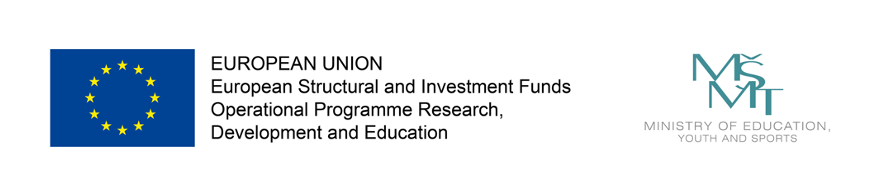

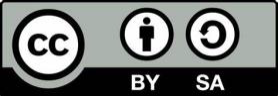

## Spatial Sampling 

using K-Means clusterring and random and spatial resampling (spatial-kfold Python package). 

    1. Spatial clustering with KMeans
    2. Spatial Blocks
        2.1 Spatial resampled random blocks     
        2.2 Continuous spatial resampled blocks
    3. Plotting function 

In [1]:
# spatial k-fold package 
!pip install spatial-kfold

In [2]:
import os
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from spatialkfold.blocks import spatial_blocks 
from spatialkfold.datasets import load_ames
from spatialkfold.clusters import spatial_kfold_clusters 
from spatialkfold.plotting import spatial_kfold_plot
from spatialkfold.stats import spatial_kfold_stats

In [3]:
os.listdir()

['07_1_LAB_GeoPython_rasterio.ipynb',
 '17_3_LAB_Land_Cover_LUCAS_exercise.ipynb',
 '07_2_LAB_mlgeo_GeoPython_vector_spatial_sampling.ipynb',
 '.ipynb_checkpoints']

In [4]:
# Load ST_LUCAS data
# https://drive.google.com/file/d/13FoS6gVEf-jo2CmeyLrpT5-TG7yx5qlv/view?usp=drive_link

path = '/Users/lukas/Work/prfuk/ownCloud/Vyuka/Machine_learning_geosciences/data/LUCAS_points'
lucas_fn = os.path.join(path, 'cz_lucas_points_2018.gpkg')
lucas = gpd.read_file(lucas_fn) 

In [5]:
type(lucas)

geopandas.geodataframe.GeoDataFrame

In [6]:
lucas.head(5)

,point_id,nuts0,nuts1,nuts2,nuts3,survey_date,car_latitude,car_longitude,car_ew,gps_proj,...,photo_point,photo_north,photo_east,photo_south,photo_west,crop_residues,transect,ex_ante,survey_year,geometry
0,46142892,CZ,CZ0,CZ03,CZ031,2018-07-18,49.069319,14.011057,1,1,...,1,1,1,1,1,2,None,0,2018,POINT (4614000.337 2891999.157)
1,48462894,CZ,CZ0,CZ06,CZ064,2018-05-15,48.928761,17.175367,1,1,...,1,1,1,1,1,2,None,0,2018,POINT (4845999.938 2894003.572)
2,48042992,CZ,CZ0,CZ05,CZ053,2018-06-22,49.840966,16.724575,1,1,...,1,1,1,1,1,1,None,0,2018,POINT (4804000.378 2991999.535)
3,46142990,CZ,CZ0,CZ02,CZ020,2018-08-13,49.948833,14.080428,1,1,...,1,1,1,1,1,2,None,0,2018,POINT (4613999.413 2989999.524)
4,46582898,CZ,CZ0,CZ03,CZ031,2018-07-23,49.099955,14.616137,1,1,...,1,1,1,1,1,-1,None,0,2018,POINT (4657999.519 2897999.834)


In [8]:
lucas.shape

(5713, 74)

<Axes: >

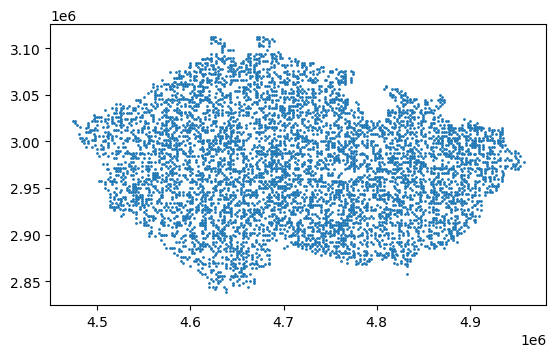

In [7]:
lucas.plot(markersize=1)

In [9]:
lucas.crs

<Projected CRS: EPSG:3035>
Name: ETRS89-extended / LAEA Europe
Axis Info [cartesian]:
- Y[north]: Northing (metre)
- X[east]: Easting (metre)
Area of Use:
- name: Europe - European Union (EU) countries and candidates. Europe - onshore and offshore: Albania; Andorra; Austria; Belgium; Bosnia and Herzegovina; Bulgaria; Croatia; Cyprus; Czechia; Denmark; Estonia; Faroe Islands; Finland; France; Germany; Gibraltar; Greece; Hungary; Iceland; Ireland; Italy; Kosovo; Latvia; Liechtenstein; Lithuania; Luxembourg; Malta; Monaco; Montenegro; Netherlands; North Macedonia; Norway including Svalbard and Jan Mayen; Poland; Portugal including Madeira and Azores; Romania; San Marino; Serbia; Slovakia; Slovenia; Spain including Canary Islands; Sweden; Switzerland; Türkiye (Turkey); United Kingdom (UK) including Channel Islands and Isle of Man; Vatican City State.
- bounds: (-35.58, 24.6, 44.83, 84.73)
Coordinate Operation:
- name: Europe Equal Area 2001
- method: Lambert Azimuthal Equal Area
Datum: Eur

## 1. Spatial clustering with KMeans

In [42]:
# 1. Spatial cluster resampling 
lucas_clusters = spatial_kfold_clusters(gdf=lucas, name='point_id', nfolds=200, 
                                       algorithm='kmeans', random_state=42)

In [43]:
lucas_clusters.head(3)

,point_id,nuts0,nuts1,nuts2,nuts3,survey_date,car_latitude,car_longitude,car_ew,gps_proj,...,photo_north,photo_east,photo_south,photo_west,crop_residues,transect,ex_ante,survey_year,geometry,folds
0,46142892,CZ,CZ0,CZ03,CZ031,2018-07-18,49.069319,14.011057,1,1,...,1,1,1,1,2,None,0,2018,POINT (4614000.337 2891999.157),16
1,48462894,CZ,CZ0,CZ06,CZ064,2018-05-15,48.928761,17.175367,1,1,...,1,1,1,1,2,None,0,2018,POINT (4845999.938 2894003.572),173
2,48042992,CZ,CZ0,CZ05,CZ053,2018-06-22,49.840966,16.724575,1,1,...,1,1,1,1,1,None,0,2018,POINT (4804000.378 2991999.535),36


In [44]:
np.sort(lucas_clusters['folds'].unique())

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

In [45]:
# Plot with colors 
cols_tab = cm.get_cmap('tab20', 10)
cols = [cols_tab(i) for i in range(10)]
color_ramp = ListedColormap(cols)

/var/folders/51/76h6b4vd7s99rjzbn4t681_h0000gp/T/ipykernel_1744/2426815093.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cols_tab = cm.get_cmap('tab20', 10)


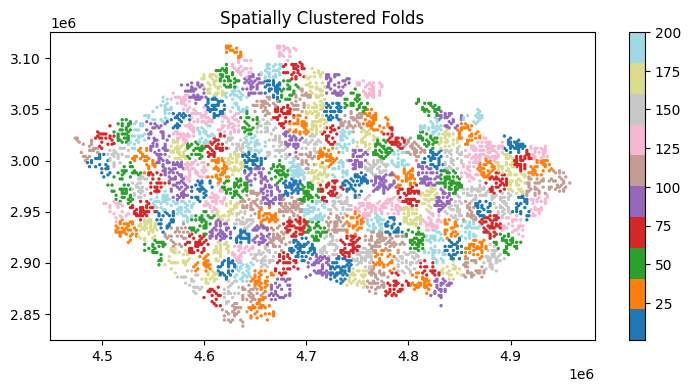

In [46]:
# Plot 
fig, ax = plt.subplots(1,1 , figsize=(9, 4)) 
lucas_clusters.plot(column='folds', ax=ax, cmap= color_ramp, markersize = 2, legend=True)
ax.set_title('Spatially Clustered Folds')
plt.show()

In [47]:
# check the number of train and test of the dependent variable for each fold
# lc1 attribute .. LUCAS Land Cover classification 
lucas_clusters_stats = spatial_kfold_stats(X=lucas_clusters, y= lucas_clusters.lc1, 
                                          groups = lucas_clusters.folds)

In [48]:
lucas_clusters_stats

,split,train,test
0,1,5689,24
1,2,5688,25
2,3,5686,27
3,4,5692,21
4,5,5682,31
...,...,...,...
195,196,5685,28
196,197,5690,23
197,198,5675,38
198,199,5687,26


## 2. Spatial Blocks

### 2.1 spatial resampled random blocks  

In [49]:
# create 10 random blocks 
lucas_rnd_blocks = spatial_blocks(gdf=lucas, width=25000, height=25000, 
                                 method='random', nfolds=10, 
                                 random_state=42)

In [50]:
lucas_rnd_blocks.head()

,geometry,folds
15,"POLYGON ((4573992.424 2888000.000, 4573992.424...",1
94,"POLYGON ((4773992.424 2863000.000, 4773992.424...",1
152,"POLYGON ((4973992.424 2963000.000, 4973992.424...",1
105,"POLYGON ((4798992.424 2913000.000, 4798992.424...",1
109,"POLYGON ((4798992.424 3013000.000, 4798992.424...",1


Text(0.5, 1.0, 'Random Blocks Folds')

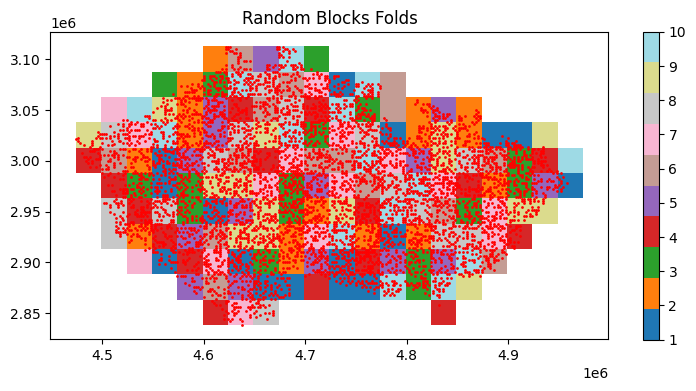

In [51]:
fig, ax = plt.subplots(1,1 , figsize=(9, 4)) 

lucas_rnd_blocks.plot(column = 'folds',cmap = color_ramp, ax = ax ,lw=0.7, legend = True)
lucas.plot(ax=ax,  markersize = 1, color = 'r')
ax.set_title('Random Blocks Folds')

In [ ]:
# Resample the data with the prepared blocks 

In [53]:
lucas['lc1']

0       C10
1       A30
2       A30
3       A30
4       A22
       ... 
5708    A11
5709    A11
5710    G11
5711    A12
5712    A21
Name: lc1, Length: 5713, dtype: object

In [54]:
lucas_rnd_blocks.head()

,geometry,folds
15,"POLYGON ((4573992.424 2888000.000, 4573992.424...",1
94,"POLYGON ((4773992.424 2863000.000, 4773992.424...",1
152,"POLYGON ((4973992.424 2963000.000, 4973992.424...",1
105,"POLYGON ((4798992.424 2913000.000, 4798992.424...",1
109,"POLYGON ((4798992.424 3013000.000, 4798992.424...",1


In [55]:
lucas_res_rnd_blk = gpd.overlay(lucas, lucas_rnd_blocks)

In [56]:
lucas_res_rnd_blk.head(3)

,point_id,nuts0,nuts1,nuts2,nuts3,survey_date,car_latitude,car_longitude,car_ew,gps_proj,...,photo_north,photo_east,photo_south,photo_west,crop_residues,transect,ex_ante,survey_year,folds,geometry
0,46142892,CZ,CZ0,CZ03,CZ031,2018-07-18,49.069319,14.011057,1,1,...,1,1,1,1,2,None,0,2018,7,POINT (4614000.337 2891999.157)
1,46042902,CZ,CZ0,CZ03,CZ031,2018-06-27,49.163753,13.880740,1,1,...,1,1,1,1,2,None,0,2018,7,POINT (4603998.279 2901998.720)
2,46122890,CZ,CZ0,CZ03,CZ031,2018-07-18,49.052706,13.981760,1,1,...,1,1,1,1,2,None,0,2018,7,POINT (4611997.995 2890031.651)


Text(0.5, 1.0, 'Spatially Resampled\nRandom Blocks')

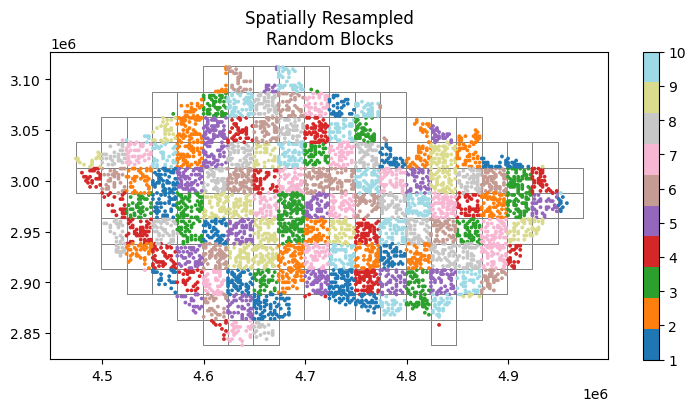

In [57]:
# plot the resampled blocks
fig, ax = plt.subplots(1,1 , figsize=(9, 4)) 

lucas_rnd_blocks.plot(facecolor="none",edgecolor='grey', ax = ax ,lw=0.7)
lucas_res_rnd_blk.plot(column = 'folds', cmap = color_ramp,legend = True, ax = ax, markersize = 3)
ax.set_title('Spatially Resampled\nRandom Blocks')

In [58]:

lucas_res_rnd_blk_stats = spatial_kfold_stats(X=lucas_res_rnd_blk, y= lucas_res_rnd_blk.lc1, 
                                             groups = lucas_res_rnd_blk.folds)


In [59]:
lucas_res_rnd_blk_stats

,split,train,test
0,1,5212,532
1,2,5142,602
2,3,5101,643
3,4,5224,520
4,5,5137,607
5,6,5160,584
6,7,5147,597
7,8,5154,590
8,9,5237,507
9,10,5182,562


### 2.2 Continuous spatial resampled blocks
Two option are availble with orientation :

'tb-lr' : top-bottom, left-right

'bt-rl' : bottom-top, right-left

In [60]:
lucas_cont_blocks = spatial_blocks(gdf=lucas, width=25000, height=25000, 
                                  method='continuous', orientation='tb-lr' ,
                                  nfolds=20, random_state=42)

Text(0.5, 1.0, 'Continuous Blocks Folds\norientation:"tb-lr"')

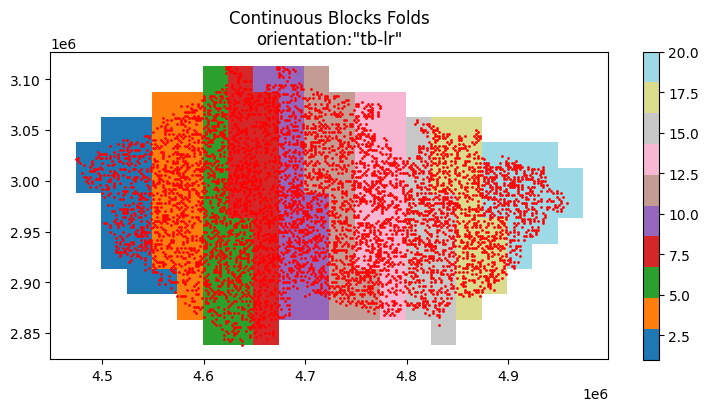

In [61]:
fig, ax = plt.subplots(1,1 , figsize=(9, 4)) 

lucas_cont_blocks.plot(column = 'folds',cmap = color_ramp, ax = ax ,lw=0.7, legend = True)
lucas.plot(ax=ax,  markersize = 1, color = 'r')
ax.set_title('Continuous Blocks Folds\norientation:"tb-lr"')

In [62]:
# resample the ames data with the prepared blocks 
lucas_res_cont_blk = gpd.overlay(lucas, lucas_cont_blocks)

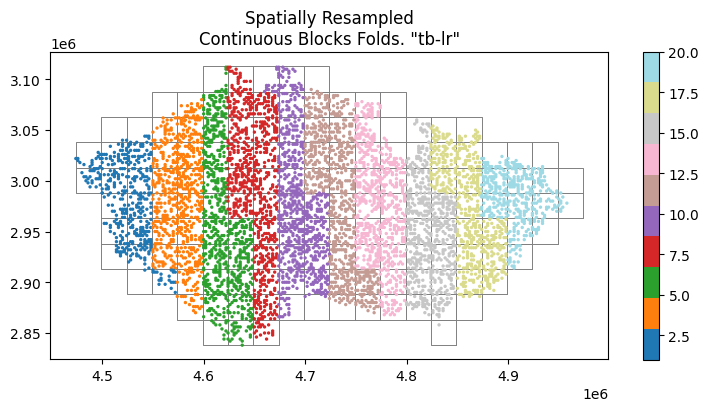

In [63]:
fig, ax = plt.subplots(1,1 , figsize=(9, 4)) 

lucas_cont_blocks.plot(facecolor="none",edgecolor='grey', ax = ax ,lw=0.7)
lucas_res_cont_blk.plot(column = 'folds', cmap = color_ramp,legend = True, ax = ax, markersize = 2)
ax.set_title('Spatially Resampled\nContinuous Blocks Folds. "tb-lr"')
plt.show()

In [64]:
lucas_res_cont_blk_stats = spatial_kfold_stats(X=lucas_res_cont_blk, y=lucas_res_cont_blk.lc1, 
                                              groups=lucas_res_cont_blk.folds)

In [65]:
lucas_res_cont_blk_stats

,split,train,test
0,1,5582,162
1,2,5511,233
2,3,5495,249
3,4,5400,344
4,5,5441,303
5,6,5408,336
6,7,5403,341
7,8,5408,336
8,9,5385,359
9,10,5436,308


## 3. Plotting function
Plot the partitioning of the data at each fold

In [66]:
# check the folds number 
np.unique(lucas_clusters.folds.values)

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

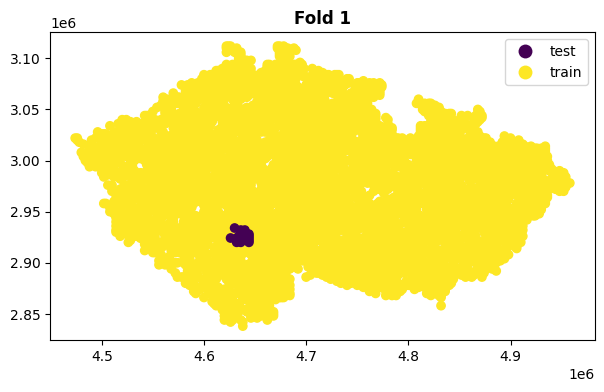

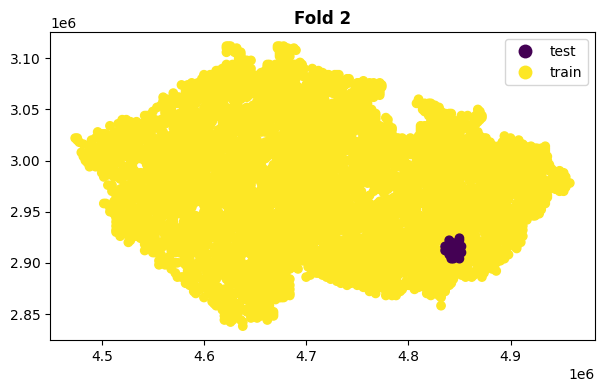

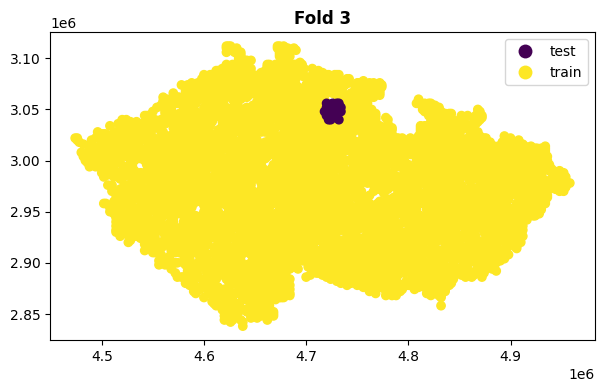

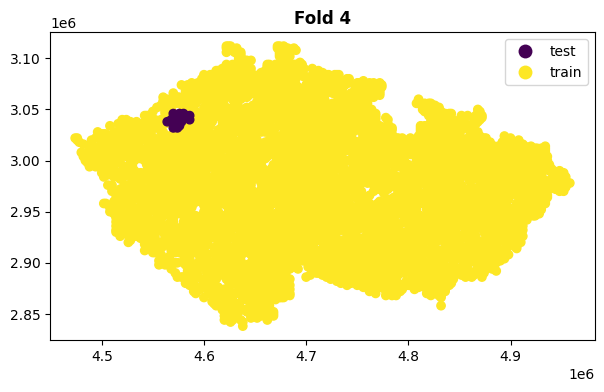

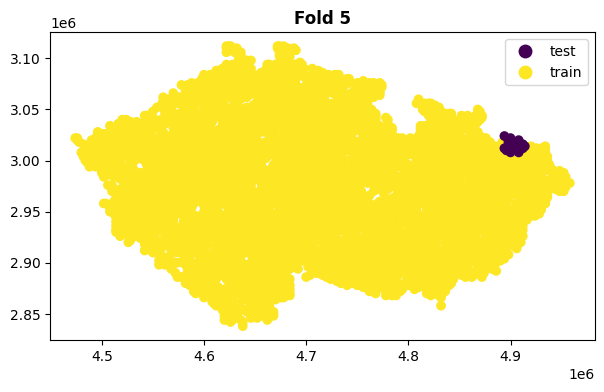

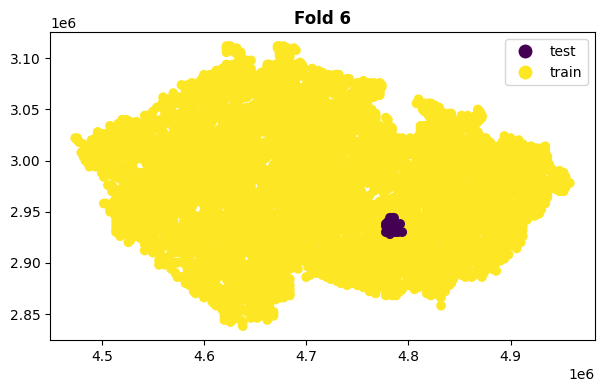

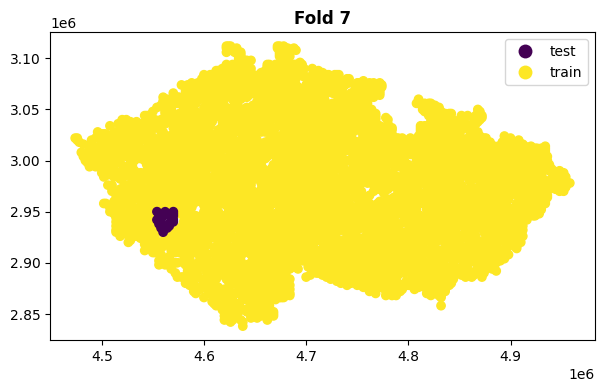

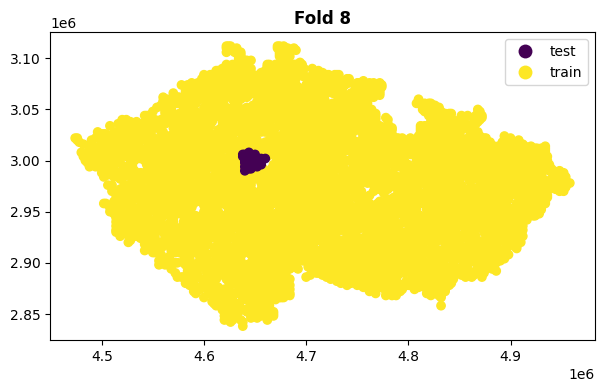

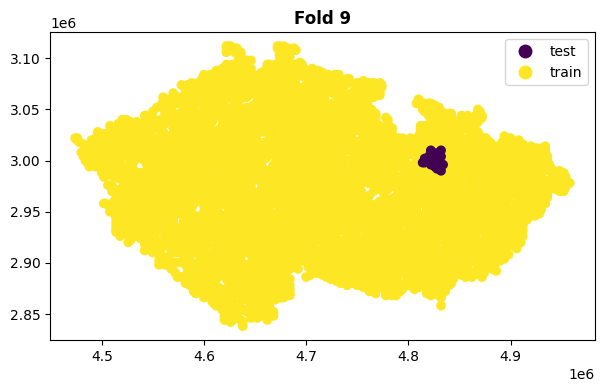

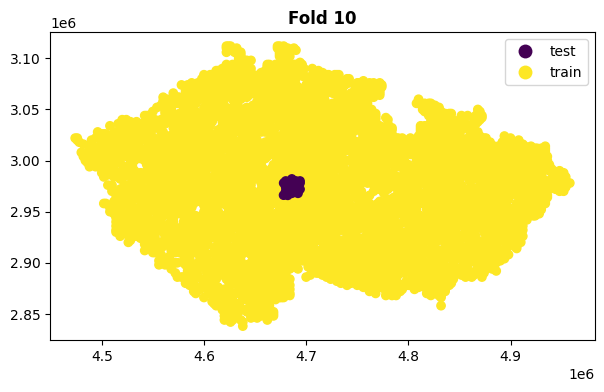

In [67]:
for i in range(1,11):
    fig, ax = plt.subplots(1,1 , figsize=(9, 4))

    spatial_kfold_plot(X=lucas_clusters, 
                       geometry=lucas_clusters.geometry, 
                       groups=lucas_clusters.folds, 
                       fold_num=i, cmap='viridis', ax=ax)    